## Introduction

### Problem Statement

Forecasting cryptocurrency prices, particularly Bitcoin, is a challenging yet valuable task due to the asset’s high volatility and market sensitivity. Investors, analysts, and trading platforms rely on timely insights to make informed decisions. The problem this project addresses is: how can we build a reliable, real-time forecasting system that predicts short-term Bitcoin price movements using both historical and live data? By leveraging Facebook Prophet, a time series forecasting tool, the project aims to process noisy and irregular financial data, model seasonality and trends, and produce accurate, interpretable forecasts. The solution must also be robust to missing data, flexible for customization, and scalable enough for real-time applications.

---

### Learning Objectives
- Apply Facebook Prophet to real-world time series data.
- Ingest real-time Bitcoin prices from a public API.
- Clean, transform, and merge historical and live data.
- Visualize trends and generate 7–30 day forecasts.
- Evaluate forecasting accuracy using RMSE/MAE.
- Build an interactive web dashboard using Streamlit.

---

### Technologies Used

| Component        | Library/Tool        |
|------------------|---------------------|
| Forecasting      | `prophet`           |
| Data Handling    | `pandas`, `numpy`   |
| API Access       | `requests`, `json`  |
| Visualization    | `matplotlib`, `plotly` |
| Evaluation       | `sklearn.metrics`   |
| Web Dashboard    | `streamlit`         |      

---

### Key Features of Facebook Prophet
- Automatic detection of yearly, weekly, and daily seasonality.
- Robust to missing data and outliers.
- Supports holiday effects and custom seasonality.
- User-friendly syntax for rapid experimentation and tuning.

---

### Data Sources
- **Historical Data**: Kaggle Bitcoin dataset (2013–2025)
- **Real-Time Data**: CoinGecko API – `/coins/bitcoin/market_chart`

---

### Python Libraries Required
- `prophet`
- `pandas`
- `numpy`
- `matplotlib`
- `plotly`
- `requests`
- `sklearn.metrics`
- `streamlit` 


## **DATA INGESTION**

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../scripts'))

In [2]:
from utils import (load_historical_data,fetch_live_data,merge_and_clean_data,create_prophet_model,
                             train_prophet_model,make_forecast,plot_forecast)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
%matplotlib inline
import seaborn as sns
import requests
import warnings
import scipy.stats as stats
from scipy.stats import shapiro, normaltest,zscore
warnings.filterwarnings('ignore')

In [4]:
# Load historical Bitcoin data
historical_btc_df = load_historical_data('../data/bitcoin_historical_data.csv')
historical_btc_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [5]:
# Fetch live Bitcoin prices from API
live_btc_df = fetch_live_data(days=365, currency='usd')
live_btc_df.head()

,ds,y
0,2024-05-01,60749.472092
1,2024-05-02,58297.574075
2,2024-05-03,59135.173361
3,2024-05-04,62839.340736
4,2024-05-05,63820.451903


In [6]:
# Merge historical and live data
bitcoin_data_df = merge_and_clean_data(historical_btc_df, live_btc_df)
bitcoin_data_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [7]:
bitcoin_data_df.shape

(4869, 2)

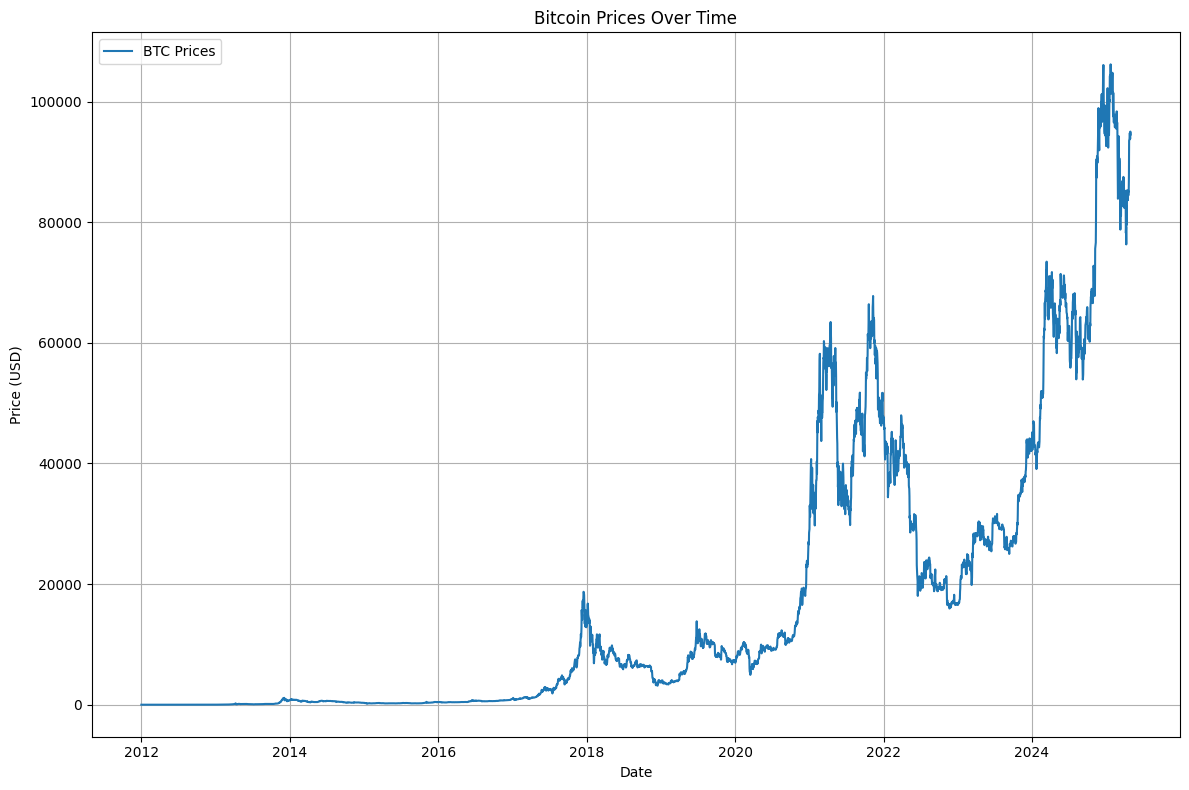

In [8]:
plt.figure(figsize=(12,8))
plt.plot(bitcoin_data_df['ds'], bitcoin_data_df['y'], label='BTC Prices')
plt.title('Bitcoin Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()  
plt.tight_layout()
plt.show()

## **EXPLORATORY DATA ANALYSIS**

### Dataset Overview

In [9]:
# Time range
print("Start Date:", bitcoin_data_df['ds'].min())
print("End Date:", bitcoin_data_df['ds'].max())

Start Date: 2012-01-01 00:00:00
End Date: 2025-04-30 00:00:00


In [10]:
# Total records 
print("total Daily records:",len(bitcoin_data_df))

total Daily records: 4869


In [11]:
print('Statistics Summary of our Dataset:')
bitcoin_data_df.describe()

Statistics Summary of our Dataset:


,ds,y
count,4869,4869.000000
mean,2018-08-31 00:00:00,17399.557222
min,2012-01-01 00:00:00,4.380000
25%,2015-05-02 00:00:00,424.450000
50%,2018-08-31 00:00:00,6603.820000
75%,2021-12-30 00:00:00,27267.000000
max,2025-04-30 00:00:00,106182.236820
std,NaN,24044.352303


### DATA QUALITY CHECKS

In [12]:
print("The number of missing entries:")
bitcoin_data_df.isnull().sum()

The number of missing entries:


ds    0
y     0
dtype: int64

In [13]:
# Check for missing days (gap in timeline)
expected_dates = pd.date_range(start=bitcoin_data_df['ds'].min(), end=bitcoin_data_df['ds'].max(), freq='D')
actual_dates = pd.to_datetime(bitcoin_data_df['ds'])
missing_days = expected_dates.difference(actual_dates)
print(f"\nNumber of missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print("Missing dates:", missing_days[:5])


Number of missing days: 0


We verified that the dataset has no missing values in either the ds (date) or y (price) columns, and there are no missing days in the time series. This confirms that the data is clean, complete, and continuous which is ideal for Facebook Prophet, as it relies on regular daily intervals to accurately model trends and seasonality.

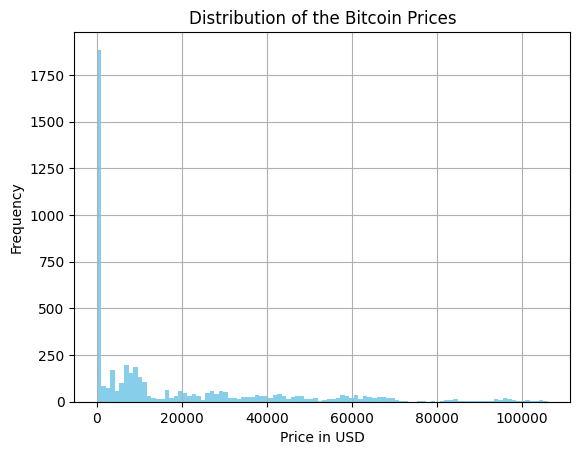

In [14]:
# understanding distribution of the data
plt.hist(bitcoin_data_df['y'],bins=100,color='skyblue')
plt.title('Distribution of the Bitcoin Prices')
plt.xlabel('Price in USD')
plt.ylabel('Frequency')
plt.grid(True)

The distribution of Bitcoin prices is highly right-skewed, with most prices concentrated in the lower range (under 10,000 dollars). A sharp peak is observed at low price levels, while higher prices (above 20,000 dollars) occur less frequently but stretch out over a long tail up to 100,000+ dollars. This confirms the presence of extreme outliers and exponential growth over time.

Text(0.5, 1.0, 'QQ Plot for the bitcoin Prices')

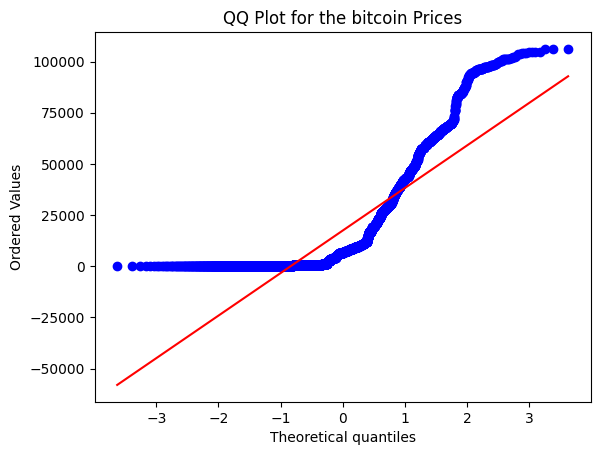

In [15]:
stats.probplot(bitcoin_data_df['y'], dist="norm",plot=plt)
plt.title("QQ Plot for the bitcoin Prices")

The QQ plot shows that Bitcoin prices are **not normally distributed**, with heavy right skew and extreme outliers. This is typical for financial time series and justifies using models like **Prophet**, which don't assume normality.